# Titanic Dataset Preprocessing

Learn Machine Learning preprocessing step by step using the Titanic dataset

## Objective

The objective of this project is to build a Machine Learning model that predicts whether a passenger survived the Titanic disaster based on features such as age, gender, passenger class, fare, family size, and embarkation port.

The project covers the complete Machine Learning workflow, including:

- Understanding the dataset
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Model Building
- Model Evaluation
- Model Comparison


## Problem Statement

The Titanic dataset contains information about passengers who travelled on the Titanic.

Using passenger information, the goal is to predict whether a passenger survived (1) or did not survive (0).

This is a Binary Classification problem because the target variable has only two classes.

## Dataset Information

- Total Rows: 891
- Total Columns: 12

Target Variable:
- Survived

Features:
- PassengerId
- Pclass
- Name
- Sex
- Age
- SibSp
- Parch
- Ticket
- Fare
- Cabin
- Embarked

## Machine Learning Workflow

1. Load Dataset
2. Understand Dataset
3. Data Quality Check
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Data Preprocessing
7. Train-Test Split
8. Model Building
9. Model Evaluation
10. Model Comparison
11. Conclusion

## Expected Outcome

At the end of this project, we aim to:

- Understand the characteristics of the Titanic dataset.
- Perform proper data preprocessing.
- Build Machine Learning models for survival prediction.
- Compare multiple algorithms.
- Select the best-performing model based on evaluation metrics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/train.csv')

# Dataset Overview

## Objective

The first step is to understand the structure of the dataset. This includes checking the number of rows and columns, data types, missing values, duplicate records, and basic statistical information. Understanding the dataset helps identify potential data quality issues before performing Exploratory Data Analysis (EDA) or building Machine Learning models.

In [3]:
df.shape

(891, 12)

In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

### Observation

- The dataset contains **891 rows** and **12 columns**.
- Each row represents one passenger.
- Each column represents a feature describing the passenger or the target variable.

In [5]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Observation

- The dataset contains both **numerical** and **categorical** features.
- Some columns contain missing values, such as **Age**, **Cabin**, and **Embarked**.
- Most numerical columns are stored as integers or floating-point numbers, while text-based columns are stored as object data types.

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [9]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
652,653,0,3,"Kalvik, Mr. Johannes Halvorsen",male,21.00,0,0,8475,8.4333,NaN,S
225,226,0,3,"Berglund, Mr. Karl Ivar Sven",male,22.00,0,0,PP 4348,9.3500,NaN,S
837,838,0,3,"Sirota, Mr. Maurice",male,NaN,0,0,392092,8.0500,NaN,S
817,818,0,2,"Mallet, Mr. Albert",male,31.00,1,1,S.C./PARIS 2079,37.0042,NaN,C


In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Observation

- The statistical summary provides information about the distribution of numerical features.
- It includes count, mean, standard deviation, minimum, maximum, and quartile values.
- These statistics help identify possible outliers and understand the spread of numerical data.

In [11]:
df.describe(include = "object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [12]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [13]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Observation

- Missing values are present in multiple columns.
- **Age** contains a moderate number of missing values.
- **Cabin** contains a very high percentage of missing values.
- **Embarked** contains only a few missing values.
- Missing values must be handled before training the Machine Learning model.

In [14]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
886,False
887,False
888,False
889,False


In [15]:
df.duplicated().sum()

np.int64(0)

### Observation

- The dataset contains no duplicate rows.
- Therefore, no duplicate records need to be removed.

## Initial Understanding

From the initial exploration, the dataset contains a combination of numerical and categorical features with some missing values. Before building a Machine Learning model, it is necessary to perform data cleaning, Exploratory Data Analysis (EDA), feature engineering, and preprocessing to prepare the data for training.

# Univariate Exploratory Data Analysis (EDA)

## Objective

The objective of univariate analysis is to study each feature individually to understand its distribution, identify missing values, detect outliers, and gain insights before performing feature engineering and model building.

# 1. Target Variable (Survived)
### Objective
To understand the distribution of the target variable.


In [16]:
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [17]:
df["Survived"].value_counts(normalize=True)*100

,proportion
Survived,
0,61.616162
1,38.383838


<Axes: xlabel='Survived', ylabel='count'>

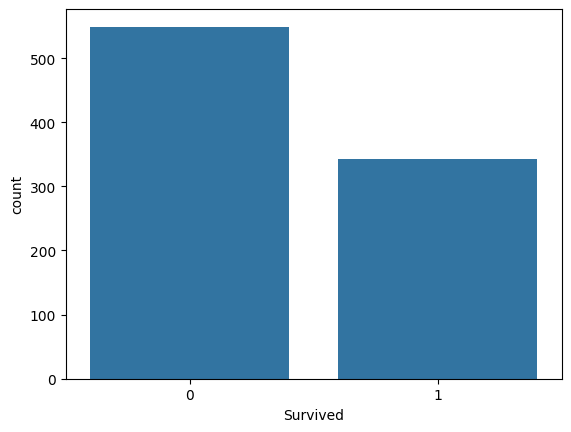

In [18]:
sns.countplot(x="Survived", data=df)

### Observations
- **Data Type**: Categorical (Binary)
- **Distribution**:61.61% passengers did not survive,while 38.38% survived.
- **Important Finding**: The dataset is slightly imbalanced.
- **Future Action**: This column will be used as the target variable during model training.


# 2. PassengerId
### Objective
To examine whether the PassengerId column is useful for prediction



In [19]:
df["PassengerId"].is_unique

True

In [20]:
df["PassengerId"].isnull().sum()

np.int64(0)

### Observations
- **Data Type**: Numerical(Identifier)
- **Missing Value**: No missing values.
- **Important Finding**:  Every passenger has a unique PassengerId.
- **Future Action**: This column is only an identifier and will likely be removed before model training.

## 3. Pclass

In [21]:
df["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


### Observation

- Pclass is a categorical feature representing passenger class.
- Most passengers belong to the third class.
- The distribution is imbalanced across the three classes.
- Passenger class may have a significant influence on survival and will be analyzed further during bivariate analysis.

## 4. Sex

In [22]:
df["Sex"].value_counts()

,count
Sex,
male,577
female,314


<Axes: xlabel='Sex', ylabel='count'>

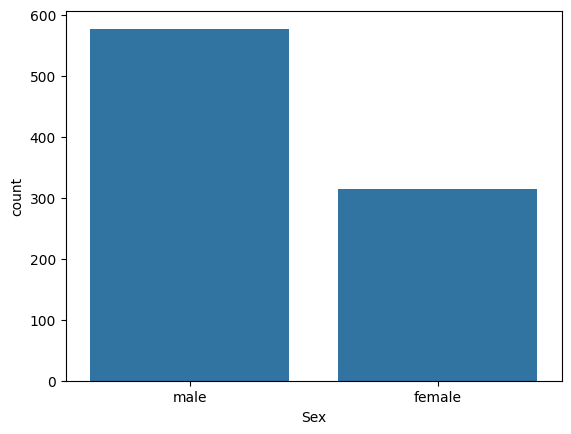

In [23]:
sns.countplot(x="Sex", data=df)

### Observation

- Sex is a categorical feature with two categories: Male and Female.
- The dataset contains more male passengers than female passengers.
- This feature is expected to have a strong relationship with survival.

## 5. Age

In [24]:
df["Age"].max()

80.0

In [25]:
df["Age"].min()*100

42.0

In [26]:
df["Age"].mean()

np.float64(29.69911764705882)

In [27]:
df["Age"].median()

28.0

(array([24.,  6., 14.,  3.,  7.,  8.,  6.,  3.,  7., 22., 13., 51., 40.,
        27., 46., 24., 36., 47., 27., 35., 17., 34., 29., 11., 27.,  8.,
        18.,  9., 17., 18.,  6., 17.,  6.,  9.,  7.,  2.,  7.,  4.,  7.,
         4.,  3.,  1.,  0.,  2.,  3.,  0.,  1.,  0.,  0.,  1.]),
 array([ 0.42  ,  2.0116,  3.6032,  5.1948,  6.7864,  8.378 ,  9.9696,
        11.5612, 13.1528, 14.7444, 16.336 , 17.9276, 19.5192, 21.1108,
        22.7024, 24.294 , 25.8856, 27.4772, 29.0688, 30.6604, 32.252 ,
        33.8436, 35.4352, 37.0268, 38.6184, 40.21  , 41.8016, 43.3932,
        44.9848, 46.5764, 48.168 , 49.7596, 51.3512, 52.9428, 54.5344,
        56.126 , 57.7176, 59.3092, 60.9008, 62.4924, 64.084 , 65.6756,
        67.2672, 68.8588, 70.4504, 72.042 , 73.6336, 75.2252, 76.8168,
        78.4084, 80.    ]),
 <BarContainer object of 50 artists>)

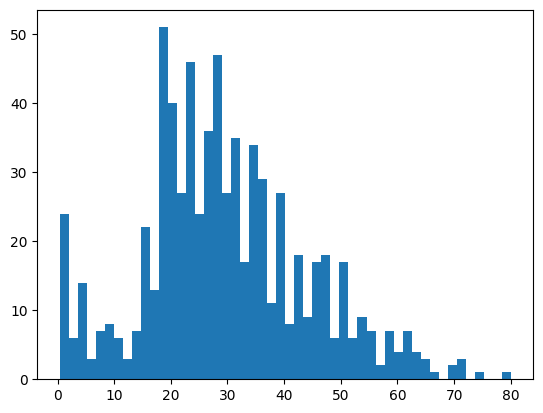

In [28]:
plt.hist(df["Age"], bins = 50)

<Axes: ylabel='Age'>

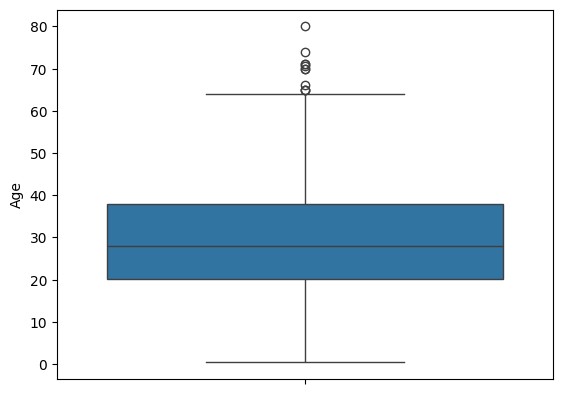

In [29]:
sns.boxplot(df["Age"])

/tmp/ipykernel_2643/2732350774.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Age"])


<Axes: xlabel='Age', ylabel='Density'>

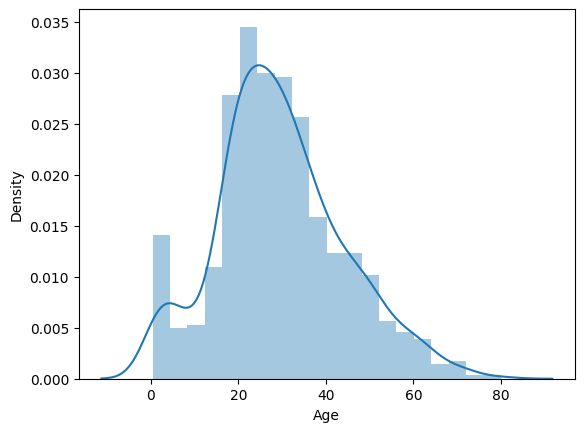

In [30]:
sns.distplot(df["Age"])

### Observation

- Age is a numerical feature.
- The distribution is approximately normal with slight skewness.
- Missing values are present and require imputation.
- Some outliers are visible.
- Age is expected to influence survival probability.

# 6.SibSp

In [31]:
df["SibSp"].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


<Axes: xlabel='SibSp', ylabel='count'>

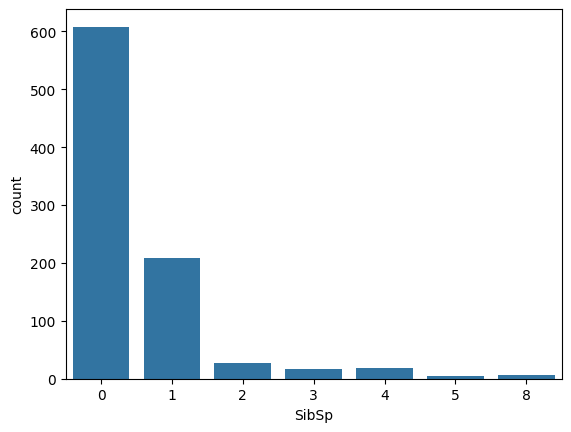

In [32]:
sns.countplot(x="SibSp",data=df)

## SibSp

### Observation

- SibSp represents the number of siblings or spouses traveling with the passenger.
- Most passengers traveled without siblings or spouses.
- The distribution is positively skewed.
- This feature may provide useful information about family relationships.

# 7. Parch

In [33]:
df["Parch"].value_counts()

,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


<Axes: xlabel='Parch', ylabel='count'>

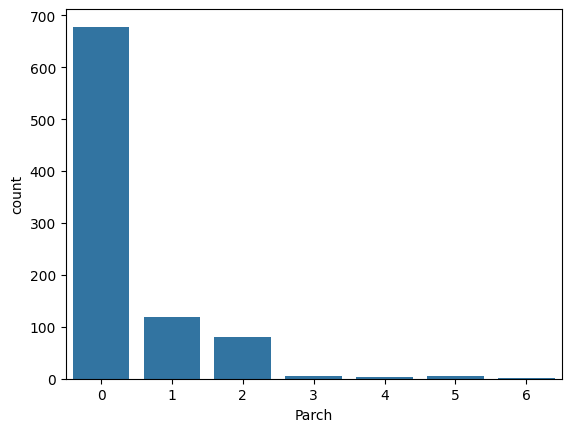

In [34]:
sns.countplot(x="Parch",data=df)

## Parch

### Observation

- Parch represents the number of parents or children traveling with the passenger.
- Most passengers traveled without parents or children.
- The feature is highly skewed toward zero.

# 8. Ticket

In [35]:
df["Ticket"].is_unique

False

In [36]:
df["Ticket"].value_counts()

,count
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6
...,...
PC 17590,1
17463,1
330877,1


## Ticket

### Observation

- Ticket contains ticket numbers in different formats.
- The feature has a high number of unique values.
- No meaningful information was extracted during this project.
- Therefore, the Ticket column will be removed before model training.

# 9. Fare

In [37]:
df["Fare"].value_counts()

,count
Fare,
8.0500,43
13.0000,42
7.8958,38
7.7500,34
26.0000,31
...,...
13.8583,1
50.4958,1
5.0000,1


In [38]:
df["Fare"].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


(array([337., 182., 147.,  50.,  16.,  39.,  18.,  29.,  18.,   2.,   8.,
          7.,   0.,   7.,   9.,   0.,   2.,   0.,   0.,   0.,   4.,   1.,
          4.,   0.,   2.,   6.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   3.]),
 array([  0.      ,  10.246584,  20.493168,  30.739752,  40.986336,
         51.23292 ,  61.479504,  71.726088,  81.972672,  92.219256,
        102.46584 , 112.712424, 122.959008, 133.205592, 143.452176,
        153.69876 , 163.945344, 174.191928, 184.438512, 194.685096,
        204.93168 , 215.178264, 225.424848, 235.671432, 245.918016,
        256.1646  , 266.411184, 276.657768, 286.904352, 297.150936,
        307.39752 , 317.644104, 327.890688, 338.137272, 348.383856,
        358.63044 , 368.877024, 379.123608, 389.370192, 399.616776,
        409.86336 , 420.109944, 430.356528, 440.603112, 450.849696,
        461.09628 , 471.342864, 481.589448, 49

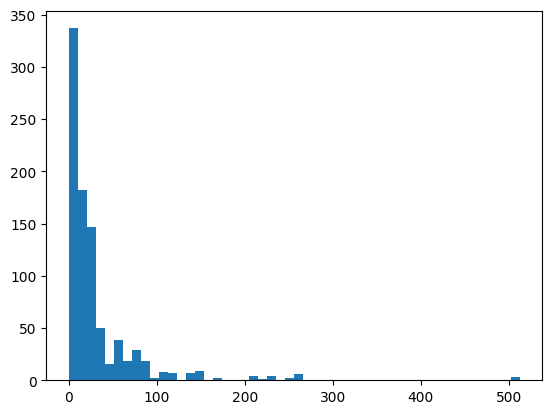

In [39]:
plt.hist(df["Fare"],bins=50)

In [40]:
df["Fare"].median()

14.4542

<Axes: ylabel='Fare'>

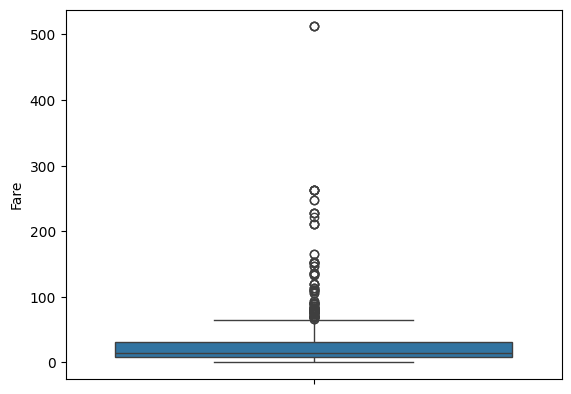

In [41]:
sns.boxplot(df["Fare"])

/tmp/ipykernel_2643/1092105540.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Fare"])


<Axes: xlabel='Fare', ylabel='Density'>

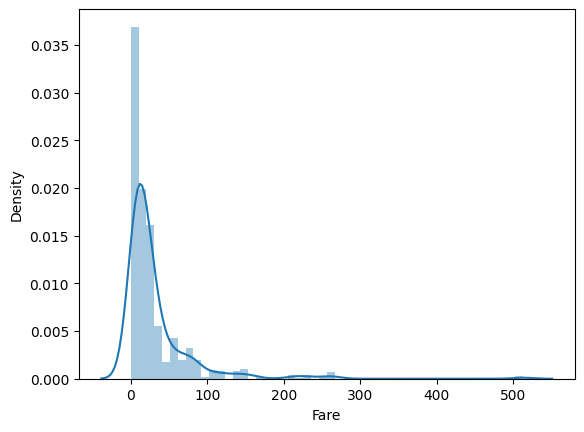

In [42]:
sns.distplot(df["Fare"])

## Fare

### Observation

- Fare is a numerical feature.
- The distribution is highly right-skewed.
- Several high-value outliers are present.
- Fare may reflect passenger class and could be an important predictor of survival.

# 10. Cabin

In [43]:
df["Cabin"].value_counts()

,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3
...,...
E17,1
A24,1
C50,1


<Axes: xlabel='Cabin', ylabel='count'>

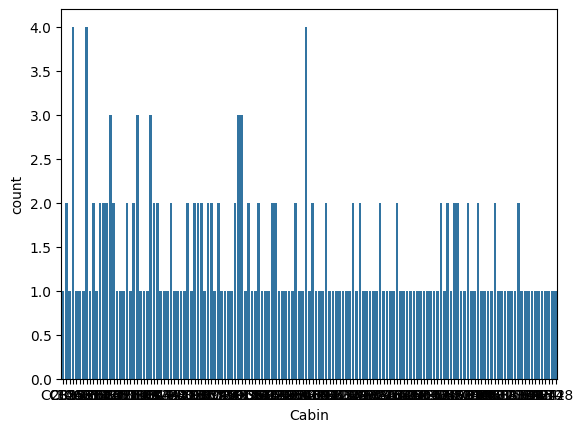

In [44]:
sns.countplot(x="Cabin",data=df)

## Cabin

### Observation

- Cabin contains a very high percentage of missing values.
- The cabin number itself has limited usefulness due to the large amount of missing data.
- However, the first letter of the cabin can be extracted as a new feature called Deck.
- The original Cabin column will be dropped after feature extraction.

# 11.Embarked

In [45]:
df["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


<Axes: xlabel='Embarked', ylabel='count'>

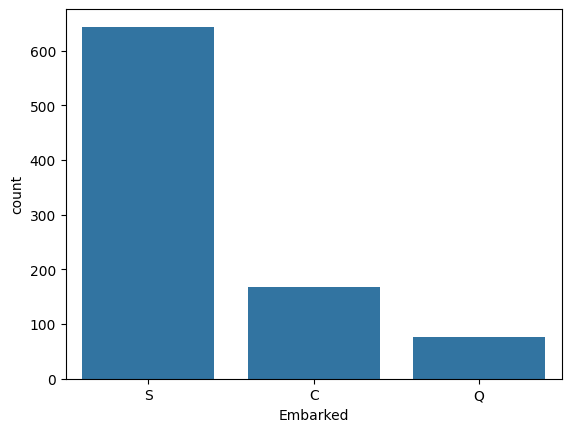

In [46]:
sns.countplot(x="Embarked",data=df)

## Embarked

### Observation

- Embarked is a categorical feature representing the port of embarkation.
- Most passengers embarked from Southampton (S).
- Only a few missing values are present.
- Missing values can be imputed using the most frequent category.

## Summary

### Key Findings

- The dataset contains both numerical and categorical features.
- Missing values are present in Age, Cabin, and Embarked.
- Fare contains significant outliers.
- Cabin has excessive missing values, so only the Deck information is retained.
- PassengerId, Ticket, and Name are not directly useful for prediction and will be removed.
- Several features, including Pclass, Sex, Age, Fare, and Embarked, are expected to influence passenger survival and will be explored further in bivariate analysis.

# Bivariate Exploratory Data Analysis (EDA)

## Objective

The objective of bivariate analysis is to study the relationship between each feature and the target variable (Survived). This helps identify which features are most influential for predicting passenger survival.

<Axes: xlabel='Sex', ylabel='count'>

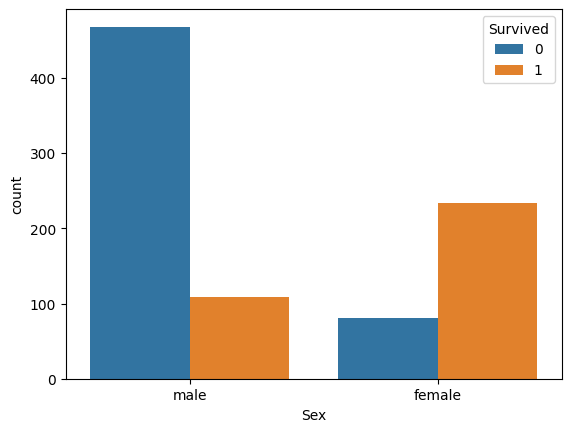

In [47]:
sns.countplot(data=df, x ="Sex", hue="Survived")

In [48]:
pd.crosstab(df["Sex"],df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [49]:
pd.crosstab(df["Sex"],df["Survived"], normalize="index")*100

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


## Sex vs Survived

### Observation

- Female passengers had a significantly higher survival rate than male passengers.
- Most male passengers did not survive.
- Sex appears to be one of the strongest predictors of survival.

<Axes: xlabel='Pclass', ylabel='count'>

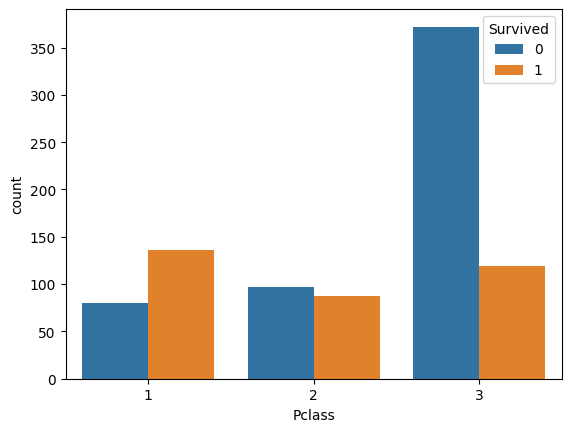

In [50]:
sns.countplot(data=df, x="Pclass" , hue="Survived")

In [51]:
pd.crosstab(df["Pclass"],df["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [52]:
pd.crosstab(df["Pclass"],df["Survived"], normalize="index")*100

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


## Pclass vs Survived

### Observation

- First-class passengers had the highest survival rate.
- Third-class passengers had the lowest survival rate.
- Passenger class shows a strong relationship with survival.

<Axes: xlabel='Embarked', ylabel='count'>

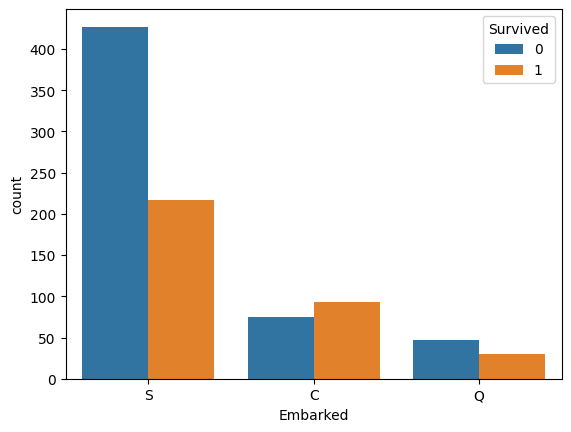

In [53]:
sns.countplot(data=df, x="Embarked" , hue="Survived")

In [54]:
pd.crosstab(df["Embarked"],df["Survived"])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


In [55]:
pd.crosstab(df["Embarked"],df["Survived"], normalize="index")*100

Survived,0,1
Embarked,,
C,44.642857,55.357143
Q,61.038961,38.961039
S,66.304348,33.695652


## Embarked vs Survived

### Observation

- Survival rates vary across different embarkation ports.
- Most passengers embarked from Southampton (S), resulting in the largest number of survivors and non-survivors from this port.
- Embarked may contribute useful information when combined with other features.

<Axes: xlabel='Survived', ylabel='Age'>

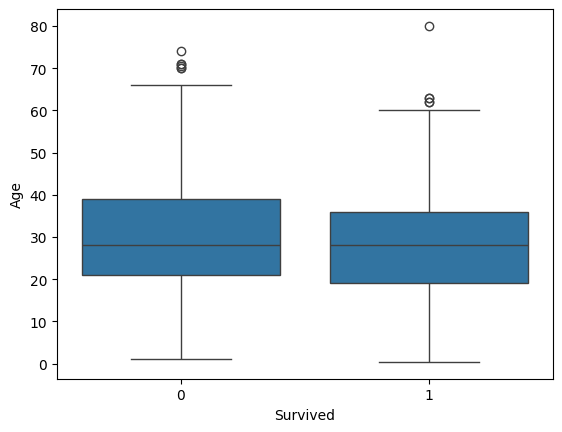

In [56]:
sns.boxplot(x="Survived", y="Age", data=df)

In [57]:
df.groupby("Survived")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,424.0,30.626179,14.172110,1.00,21.0,28.0,39.0,74.0
1,290.0,28.343690,14.950952,0.42,19.0,28.0,36.0,80.0


## Age vs Survived

### Observation

- The median age differs slightly between survivors and non-survivors.
- The age distribution overlaps considerably for both groups.
- Outliers are present in both categories.
- Age alone is not sufficient to determine survival but may improve predictions when combined with other features.

<Axes: xlabel='Survived', ylabel='Fare'>

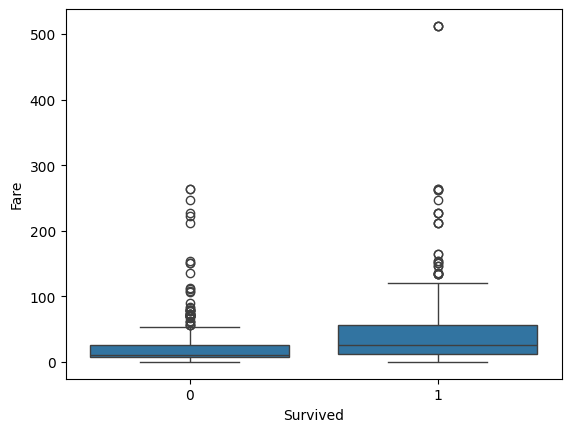

In [58]:
sns.boxplot(x="Survived", y="Fare", data=df)

In [59]:
df.groupby("Survived")["Fare"].mean()

,Fare
Survived,
0,22.117887
1,48.395408


## Fare vs Survived

### Observation

- Survivors generally paid higher fares than non-survivors.
- The median fare is higher for passengers who survived.
- Fare contains several high-value outliers.
- Fare appears to have a positive relationship with survival probability.

<Axes: >

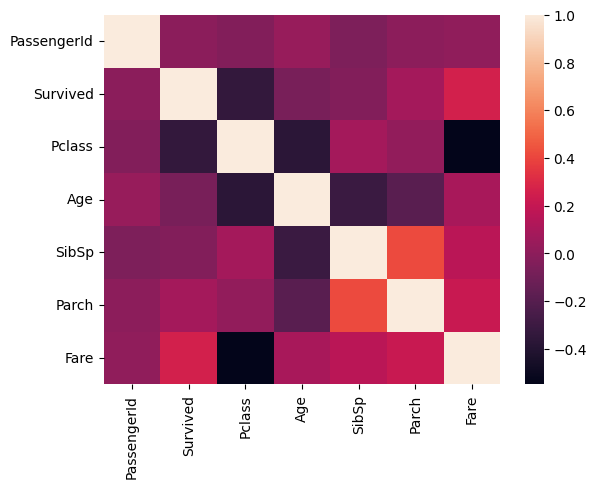

In [60]:
sns.heatmap(df.corr(numeric_only=True))

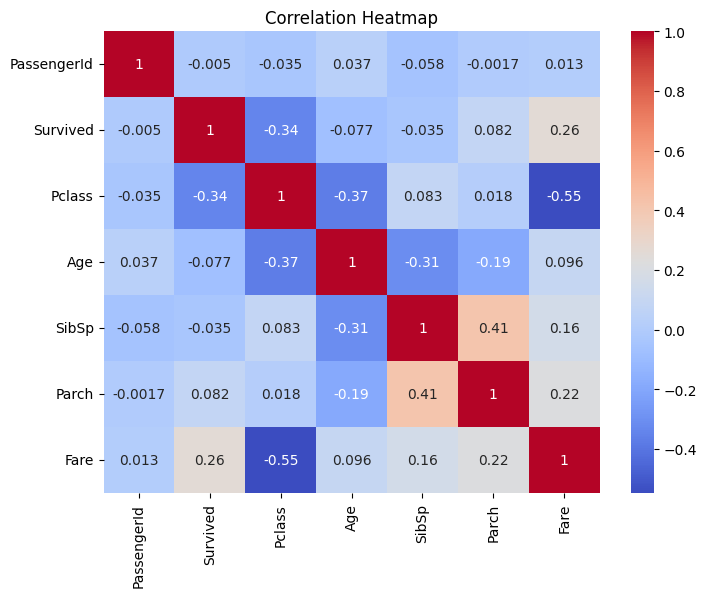

In [61]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## Correlation Heatmap

### Observation

- Most numerical features show weak to moderate correlations.
- Fare has a positive correlation with Survived.
- Pclass has a negative correlation with Survived.
- No pair of numerical features shows extremely high correlation, indicating low multicollinearity.

## Summary

### Key Findings

- Sex is one of the strongest predictors of survival.
- First-class passengers had higher survival rates than third-class passengers.
- Higher ticket fares are associated with higher survival probability.
- Age shows some influence but is not a strong predictor on its own.
- Embarked provides additional information that may improve model performance.
- The heatmap indicates no severe multicollinearity among numerical features.

# Feature Engineering

## Objective

The objective of feature engineering is to improve the quality of the dataset by creating useful features, removing unnecessary features, and preparing the data for machine learning. Well-designed features can improve model performance and make patterns easier to learn.

## PassengerId

### Action Taken

- Dropped the PassengerId column.

### Reason

PassengerId is a unique identifier assigned to each passenger. It does not contain information related to passenger survival and therefore does not contribute to model learning.

In [112]:
df.drop(columns=["PassengerId"], inplace=True)

## Name

### Action Taken

- Dropped the Name column.

### Reason

The complete passenger name is not directly useful for prediction. Although titles such as Mr, Mrs, and Miss can be extracted in advanced feature engineering, they were not used in this project.

In [113]:
df.drop(columns=["Name"], inplace=True)

## Ticket

### Action Taken

- Dropped the Ticket column.

### Reason

The Ticket column contains a large number of unique values and no meaningful pattern was extracted during this project. Therefore, it was removed to reduce unnecessary complexity.

In [74]:
df.drop(columns=["Ticket"], inplace=True)

## Cabin

### Action Taken

- Extracted the first letter of the Cabin value to create a new feature called Deck.
- Dropped the original Cabin column.

### Reason

The Cabin column contains a high percentage of missing values. However, the first letter represents the passenger's deck, which may contain useful information about passenger location on the ship. Keeping only the deck preserves useful information while reducing feature complexity.

In [73]:
df.drop(columns=["Cabin"], inplace=True)

## Missing Value Strategy

### Action Taken

- Age → Filled using the median.
- Embarked → Filled using the most frequent category (mode).
- Deck → Filled using the most frequent category (mode).

### Reason

- Median is less affected by outliers and is suitable for numerical features like Age.
- Mode is appropriate for categorical features because it replaces missing values with the most common category.

In [63]:
df["Embarked"].mode()

,Embarked
0,S


In [64]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [65]:
df["Embarked"].isnull().sum()

np.int64(0)

In [66]:
from sklearn.impute import SimpleImputer

In [67]:
age_imputer = SimpleImputer(strategy="median")

In [68]:
df["Age"] = age_imputer.fit_transform(df[["Age"]])

In [69]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [70]:
df["Cabin"].dropna().head(10)

,Cabin
1,C85
3,C123
6,E46
10,G6
11,C103
21,D56
23,A6
27,C23 C25 C27
31,B78
52,D33


In [71]:
df["Deck"] = df["Cabin"].str[0]

In [72]:
df["Deck"].value_counts(dropna=False)

,count
Deck,
NaN,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Fare         891 non-null    float64
 9   Embarked     891 non-null    object 
 10  Deck         204 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [76]:
from sklearn.preprocessing import OneHotEncoder

## Categorical Encoding

### Action Taken

Applied One-Hot Encoding to categorical features.

### Reason

Machine learning algorithms cannot work directly with text values. One-Hot Encoding converts categorical values into numerical format without introducing an artificial order between categories.

In [77]:
ohe = OneHotEncoder(handle_unknown="ignore",sparse_output=False)

## Summary

### Key Changes

- Removed PassengerId.
- Removed Name.
- Removed Ticket.
- Extracted Deck from Cabin.
- Dropped the original Cabin column.
- Filled missing values in Age, Embarked, and Deck.
- Applied One-Hot Encoding to categorical features.

These preprocessing steps produced a cleaner and more informative dataset for model training.

# Data Preprocessing

## Objective

The objective of data preprocessing is to prepare the dataset for machine learning by handling missing values, converting categorical data into numerical format, and applying the same preprocessing steps consistently to both training and testing data.

In [78]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

## Feature Categorization

### Numerical Features

- Age
- Fare
- SibSp
- Parch

### Categorical Features

- Sex
- Embarked
- Deck
- Pclass

### Reason

Different preprocessing techniques are required for numerical and categorical features.

In [79]:
categorical_features = ["Sex","Embarked","Deck","Pclass"]
numerical_features = ["Age","Fare","SibSp","Parch"]

## Numerical Pipeline

### Action Taken

Applied SimpleImputer(strategy="median") to numerical features.

### Reason

Median is less affected by outliers than the mean and is therefore suitable for numerical features containing missing values.

In [80]:
num_pipeline = Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])

## Categorical Pipeline

### Action Taken

Applied:

- SimpleImputer(strategy="most_frequent")
- OneHotEncoder(handle_unknown="ignore")

### Reason

The most frequent category is suitable for filling missing values in categorical data. One-Hot Encoding converts categorical values into numerical format while avoiding an artificial order between categories.

In [81]:
cat_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore"))])

## ColumnTransformer

### Action Taken

Combined the numerical and categorical preprocessing pipelines into a single ColumnTransformer.

### Reason

The ColumnTransformer applies the correct preprocessing steps to each feature type while keeping the preprocessing organized and reusable.

In [82]:
preprocessor = ColumnTransformer([("num", num_pipeline, numerical_features), ("cat", cat_pipeline, categorical_features)])

## Separating Features and Target

### Action Taken

The dataset was divided into:

- **X (Features):** All input columns used for prediction.
- **y (Target):** The Survived column.

### Reason

Separating the target variable from the input features is necessary because machine learning models learn the relationship between X and y.

In [83]:
X = df.drop(columns=["Survived"])

In [84]:
y = df["Survived"]

In [85]:
from sklearn.model_selection import train_test_split

## Train-Test Split

### Action Taken

The dataset was divided into training and testing sets using an 80:20 ratio.

### Reason

The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Applying the Preprocessor

### Action Taken

- Applied fit_transform() on the training data.
- Applied transform() on the testing data.

### Reason

The preprocessing pipeline learns statistics (such as the median for imputation and categories for encoding) only from the training data. The same learned transformations are then applied to the test data to prevent data leakage.

In [87]:
X_train =  preprocessor.fit_transform(X_train)

In [88]:
X_test = preprocessor.transform(X_test)

In [89]:
print(X_train.shape)

(712, 20)


In [90]:
print(X_test.shape)

(179, 20)


## Summary

### Key Steps

- Separated features and target.
- Identified numerical and categorical features.
- Created preprocessing pipelines.
- Combined them using ColumnTransformer.
- Split the dataset into training and testing sets.
- Applied fit_transform() to the training data.
- Applied transform() to the testing data.

These steps ensured that the dataset was properly prepared for machine learning while preventing data leakage.

# Model Building - Logistic Regression

## Objective

The objective of this stage is to train a Logistic Regression model using the preprocessed training data and predict passenger survival on unseen test data.

## Why Logistic Regression?

Logistic Regression is a supervised machine learning algorithm used for binary classification problems.

Since the target variable (Survived) contains only two classes (0 and 1), Logistic Regression is an appropriate baseline model for this project.

## Importing the Model

The Logistic Regression algorithm is imported from the scikit-learn library.

At this stage, no learning takes place. We are only importing the algorithm.

In [91]:
from sklearn.linear_model import LogisticRegression

## Creating the Model

A Logistic Regression model is initialized with a fixed random_state to ensure reproducible results.

At this stage, the model is empty and has not learned from the data.

In [92]:
model = LogisticRegression(random_state=42)

## Training the Model

The model is trained using the training dataset.

During training, the algorithm learns the relationship between the input features (X_train) and the target variable (y_train).

The learned relationship will later be used to make predictions on unseen data.

In [93]:
model.fit(X_train, y_train)

LogisticRegression(random_state=42)

## Making Predictions

After training, the model predicts the survival status of passengers in the test dataset.

These predictions are stored in a new variable and compared with the actual values during evaluation.

In [94]:
y_pred = model.predict(X_test)

## Summary

### Key Steps

- Imported the Logistic Regression algorithm.
- Created the model.
- Trained the model using the training data.
- Predicted passenger survival on the test data.

The trained model is now ready for performance evaluation.

# Model Evaluation

## Objective

The objective of model evaluation is to measure how well the trained Logistic Regression model performs on unseen test data. Different evaluation metrics are used to assess the model's predictive performance.

In [95]:
from sklearn .metrics import accuracy_score

In [96]:
accuracy = accuracy_score(y_test, y_pred)

In [97]:
print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


## Accuracy Score

### Result

Accuracy = **0.8100 (81%)**

### Observation

- The Logistic Regression model correctly predicted approximately **81%** of the passengers in the test dataset.
- Accuracy provides an overall measure of model performance.
- Although accuracy is useful, it should not be the only metric used for evaluation, especially for imbalanced datasets.

In [98]:
from sklearn.metrics import confusion_matrix

In [99]:
cm = confusion_matrix(y_test, y_pred)

In [100]:
print(cm)

[[90 15]
 [19 55]]


## Confusion Matrix

### Observation

The confusion matrix provides a detailed breakdown of correct and incorrect predictions.

- True Negatives (TN): **90**
- False Positives (FP): **15**
- False Negatives (FN): **19**
- True Positives (TP): **55**

The model correctly classified most passengers while making a small number of incorrect predictions.

In [101]:
from sklearn.metrics import classification_report

In [102]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



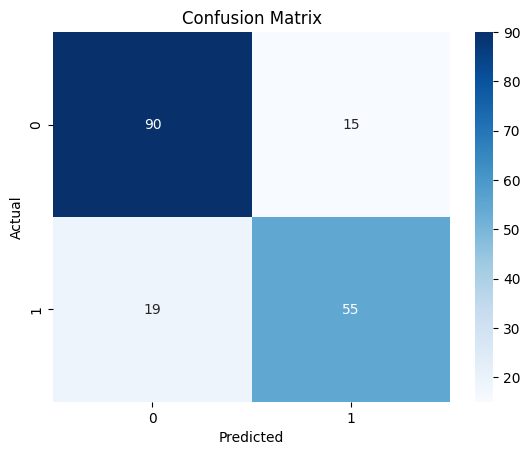

In [103]:
sns.heatmap(cm, annot = True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Classification Report

### Observation

- Class **0 (Did Not Survive)** was predicted with higher precision and recall than Class **1 (Survived)**.
- The model performed better at identifying passengers who did not survive.
- The overall performance is balanced, with good precision, recall, and F1-score values.

## Precision

Precision measures how many passengers predicted as survivors actually survived.

Result: **0.79**

### Observation

Approximately **79%** of the passengers predicted as survivors were correctly classified.

## Recall

Recall measures how many actual survivors were correctly identified.

Result: **0.74**

### Observation

The model successfully identified **74%** of all actual survivors.

## F1-Score

F1-Score is the harmonic mean of Precision and Recall.

Result: **0.76**

### Observation

The F1-Score indicates a good balance between Precision and Recall, making it a useful metric for evaluating the overall performance of the classifier.

## Overall Evaluation Summary

### Key Findings

- Logistic Regression achieved an accuracy of **81%** on the test dataset.
- The model correctly classified most passengers.
- The model performed slightly better at predicting passengers who did not survive than those who survived.
- Precision, Recall, and F1-Score indicate that the model provides balanced performance.
- Logistic Regression serves as a strong baseline model for the Titanic survival prediction task.

In [104]:
from sklearn.tree import DecisionTreeClassifier

# Model Comparison

## Objective

The objective of model comparison is to evaluate multiple machine learning algorithms using the same dataset and preprocessing pipeline. This helps identify the model that provides the best predictive performance.

In [105]:
dt_model = DecisionTreeClassifier(random_state=42)

In [106]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [107]:
y_pred_dt = dt_model.predict(X_test)

In [108]:
print(accuracy_score(y_test, y_pred_dt))

0.770949720670391


In [109]:
cm = confusion_matrix(y_test, y_pred_dt)

In [110]:
print(cm)

[[82 23]
 [18 56]]


In [111]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.82      0.78      0.80       105
           1       0.71      0.76      0.73        74

    accuracy                           0.77       179
   macro avg       0.76      0.77      0.77       179
weighted avg       0.77      0.77      0.77       179



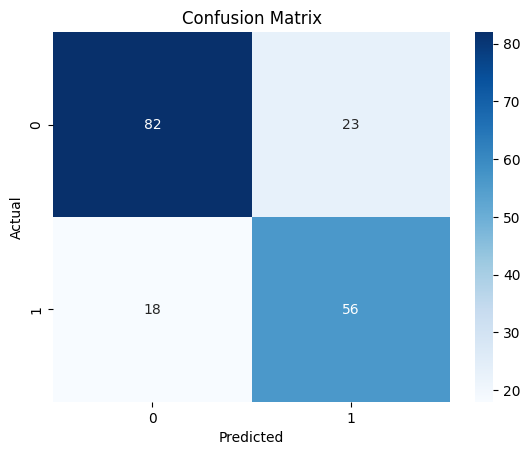

In [114]:
sns.heatmap(cm, annot = True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

| Model | Accuracy | Precision | Recall | F1-Score |
|--------|---------:|----------:|-------:|---------:|
| Logistic Regression | 0.8100 | 0.79 | 0.74 | 0.76 |
| Decision Tree | 0.7709 | *0.71* | *0.76* | *0.73* |

### Observation

- Logistic Regression achieved higher accuracy than the default Decision Tree model.
- Logistic Regression also showed balanced precision, recall, and F1-score.
- The Decision Tree model may be improved further by tuning hyperparameters such as max_depth and min_samples_split.
- At this stage, Logistic Regression is the better-performing model for the Titanic dataset.

# Final Conclusion

## Conclusion

In this project, a complete machine learning workflow was implemented to predict passenger survival on the Titanic dataset.

The project included:
- Data understanding
- Data cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Model Building
- Model Evaluation
- Model Comparison

Missing values were handled using appropriate imputation techniques, categorical features were encoded using One-Hot Encoding, and preprocessing was organized using Scikit-learn pipelines and a ColumnTransformer.

Among the models evaluated so far, Logistic Regression achieved the best performance with an accuracy of **81%**, making it the strongest baseline model for this dataset.

This project also strengthened the understanding of feature engineering, preprocessing pipelines, train-test splitting, data leakage prevention, and evaluation metrics such as Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix.

The notebook will be extended in the future by adding additional machine learning algorithms, hyperparameter tuning, and cross-validation for a more comprehensive comparison.